## Importing Libraries

Link for the dataset - https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/data

In [1]:
!pip install --upgrade pip
!pip install tensorflow

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\HP\anaconda3\envs\DL\python.exe -m pip install --upgrade pip


In [3]:
!pip install Scikit-learn Seaborn Matplotlib Librosa Librosa NumPy Streamlit

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 767.3 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/9.1 MB 767.3 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/9.1 MB 767.3 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/9.1 MB 551.8 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/9.1 MB 551.8 kB/s eta 0:00:16
   ---- ----------------------------------- 1.0/9.1 MB 567.0 kB/s eta 0:00:15
   ---- ----------------------------------- 1.0/9.1 MB 567.0 kB/s eta 0:00:15
   ---- --------------------------------

In [6]:
import os
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,Dropout
from tensorflow.keras.optimizers.legacy import Adam

c:\Users\HP\anaconda3\envs\DL\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## Visualizing Single Audio

* python package for analyse audio - https://librosa.org/doc/latest/index.html

In [ ]:
random_file_name = "blues.00000.wav" #path of random audio file name

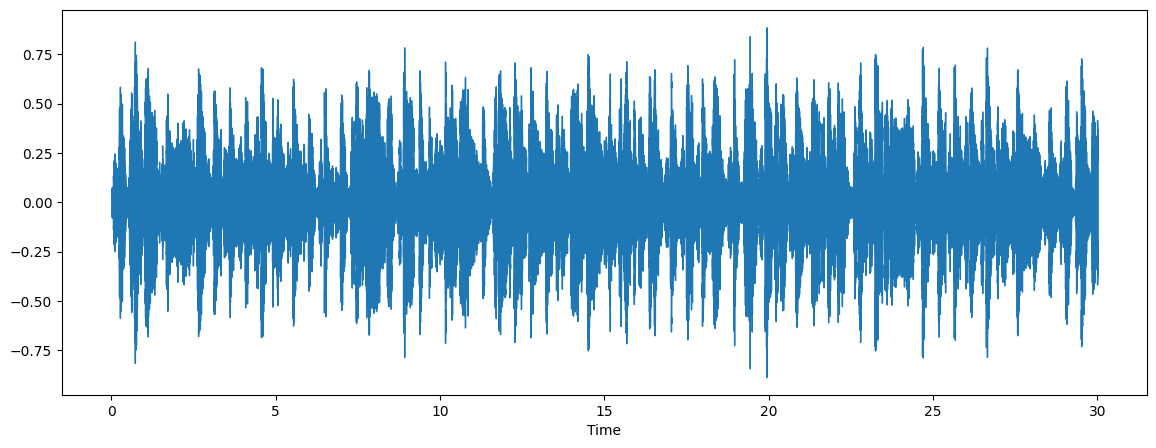

In [ ]:
y,sr = librosa.load(random_file_name,sr=44100) # load the audio file. sampling rate and file path should be given

# visualise the audio file
plt.figure(figsize=(14,5))
librosa.display.waveshow(y,sr=sr)

* x axis is time and y axis is ampolitude of the audio file
* if we give this grpah to melspectrogram and pass the model , model can't undertand the patterns and trends of the graph correctly
* we should create chunks of graphs to give better idea to the model as follows

In [55]:
y.shape

(1323588,)

## Playing Sound

In [ ]:
# play the sound of the audio file
from IPython.display import Audio
Audio(data=y,rate=sr)

In [57]:
y

array([ 0.0073492 ,  0.01335781,  0.01657649, ..., -0.07293835,
       -0.06308191, -0.03151626], dtype=float32)

### Doing Visualization on chunks of Audio

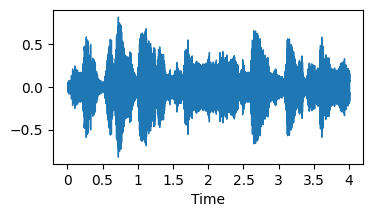

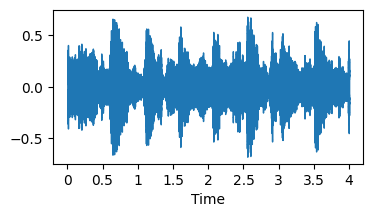

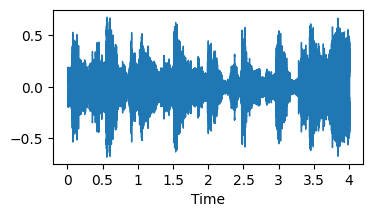

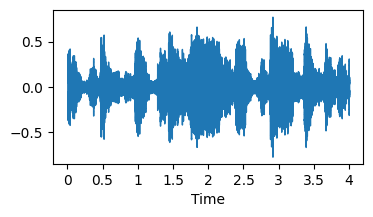

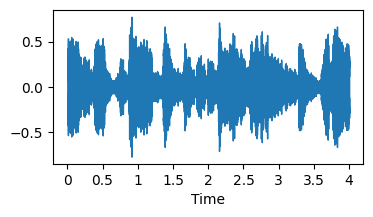

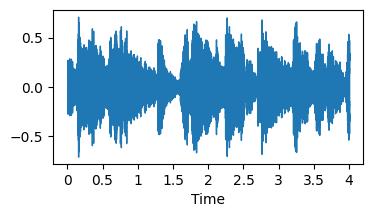

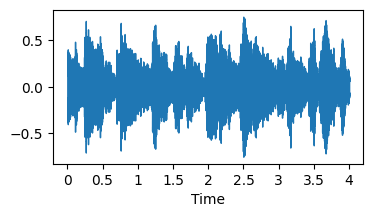

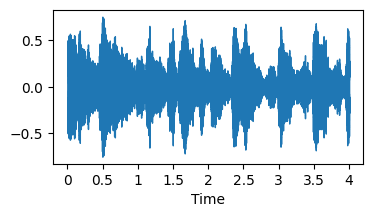

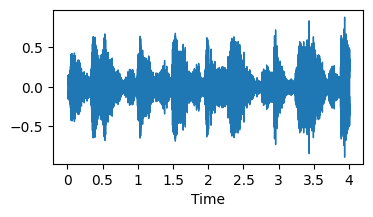

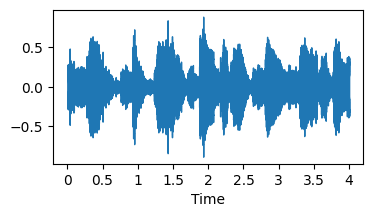

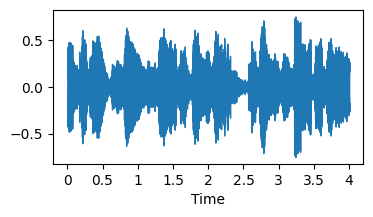

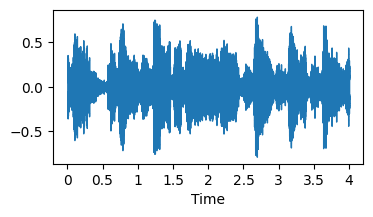

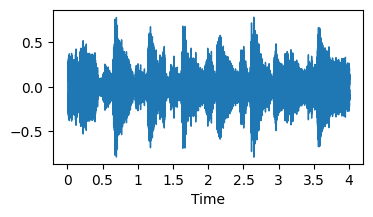

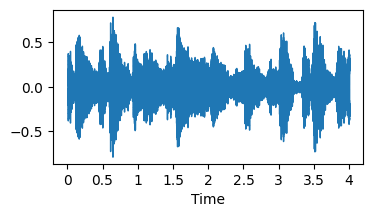

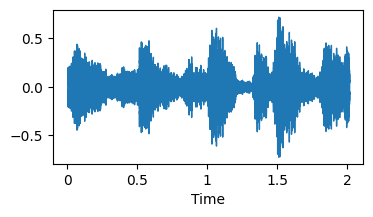

In [9]:
audio_path = "./blues.00000.wav" # random audio path
y, sr = librosa.load(audio_path, sr=None)  # sr=None to keep the original sampling rate

# Define the duration of each chunk and overlap
chunk_duration = 4  # seconds
overlap_duration = 2  # seconds
# first chunk is from 0 to 4 and second chunk is from 2 to 6 because overlapping is 2 seconds

# Convert durations to samples
chunk_samples = chunk_duration * sr
overlap_samples = overlap_duration * sr

# Calculate the number of chunks
num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

# Iterate over each chunk
for i in range(num_chunks):
    # Calculate start and end indices of the chunk
    start = i * (chunk_samples - overlap_samples)
    end = start + chunk_samples
    
    # Extract the chunk of audio
    chunk = y[start:end]
    plt.figure(figsize=(4, 2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.show()
    

* by chuncking the audio like this the model can understand the patterns and trends of the wave clearly. 
* if we give plot melspectrogram for 30 mins whole audio we give to the model only one sample. so the if have 100 audion we feed only 100 records to the model. if we give chunk melscpectrogram we can give more records to the model like augmentation. so model will get more training data and model can undertand the patterns in more better way

## Melspectrogram Visualization

In [10]:
#Plotting Melspectrogram of Entire Audio
def plot_melespectrogram(y,sr):
    #Compute spectrogram
    spectrogram = librosa.feature.melspectrogram(y=y,sr=sr)
    #Convert to decibels (log scale). this is the mel scale
    spectrogram_db = librosa.power_to_db(spectrogram,ref=np.max)
    #Visualize the spectrogram
    plt.figure(figsize=(10,4))
    librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
    plt.colorbar(format='%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()
    

In [11]:
random_file_name = "./blues.00000.wav"
y,sr = librosa.load(random_file_name,sr=44100)

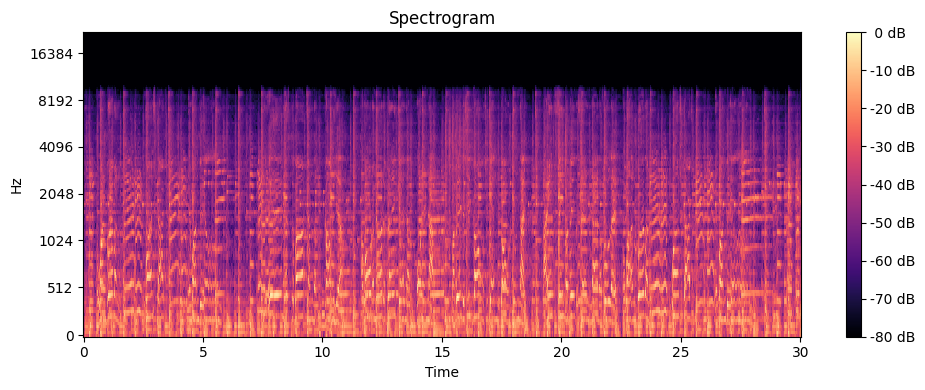

In [12]:
plot_melespectrogram(y,sr)

In [13]:
def plot_melspectrogram_chunks(y,sr):
    #define the duration of each chunk and overlap
    chunk_duration = 4
    overlap_duration = 2
    
    #Convert duration to sample
    chunk_samples = chunk_duration * sr
    overlap_samples = overlap_duration * sr
    
    #Calculate the number of chunks
    num_chunks = int(np.ceil((len(y)-chunk_samples)/(chunk_samples-overlap_samples)))+1
    
    #iterate over each chunks
    for i in range(num_chunks):
        #Calculate start and end indices of the chunk
        start = i*(chunk_samples-overlap_samples)
        end = start+chunk_samples
        #Extract the chunk audio
        chunk = y[start:end]
        #Melspectrogram part
        spectrogram = librosa.feature.melspectrogram(y=chunk,sr=sr)
        print(spectrogram.shape)
        spectrogram_db = librosa.power_to_db(spectrogram,ref=np.max)
        #Visualize the spectrogram
        plt.figure(figsize=(10,4))
        librosa.display.specshow(spectrogram_db,sr=sr,x_axis='time',y_axis='mel')
        plt.colorbar(format='%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()

In [14]:
random_file_name = "./blues.00000.wav"
y,sr = librosa.load(random_file_name,sr=44100)

(128, 345)


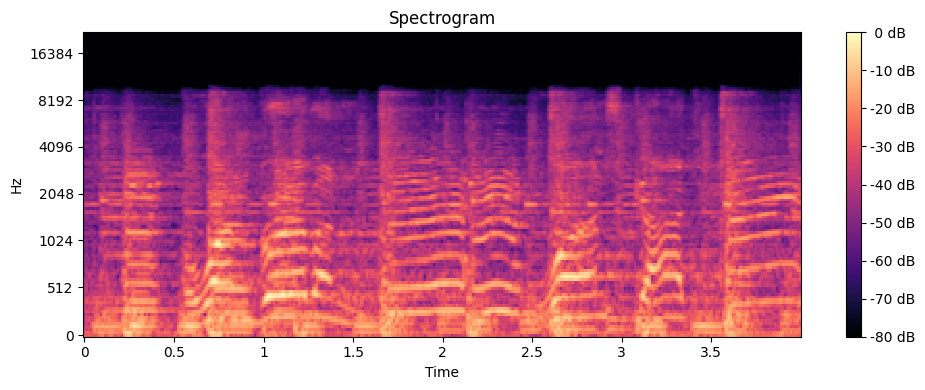

(128, 345)


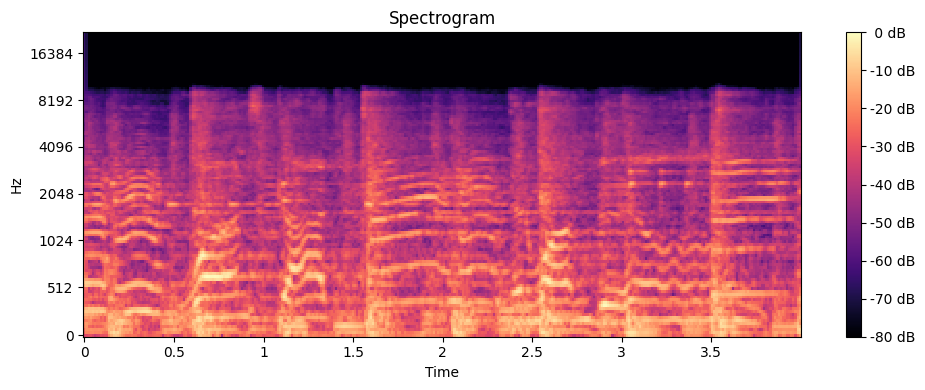

(128, 345)


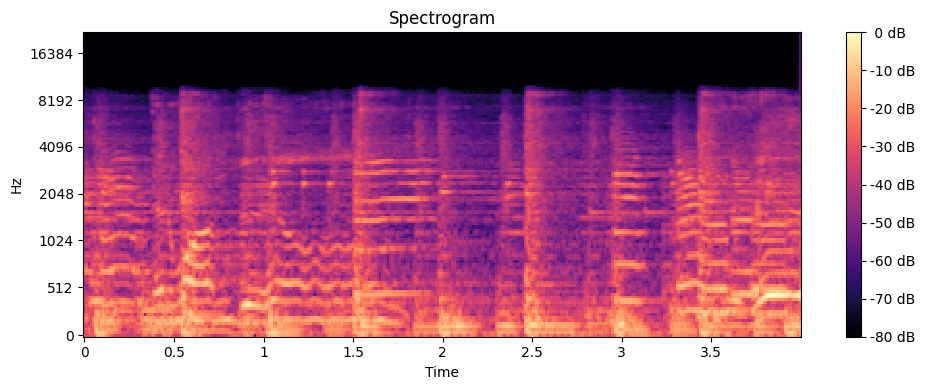

(128, 345)


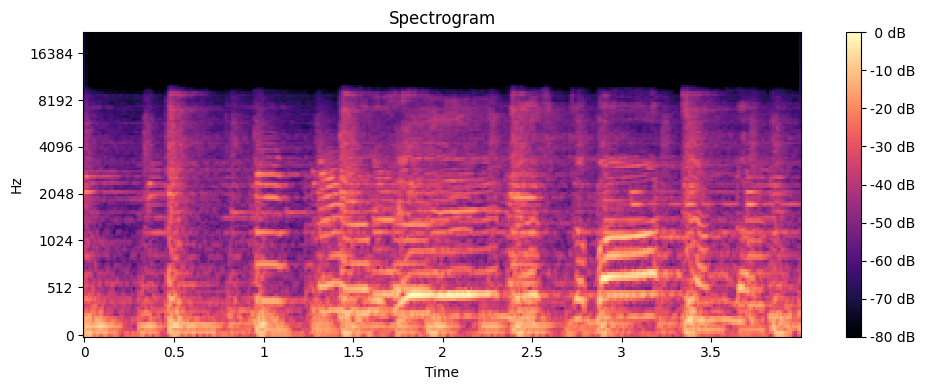

(128, 345)


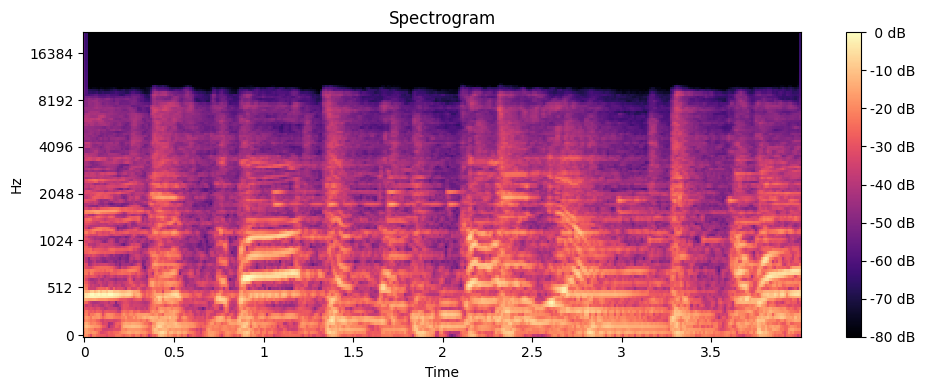

(128, 345)


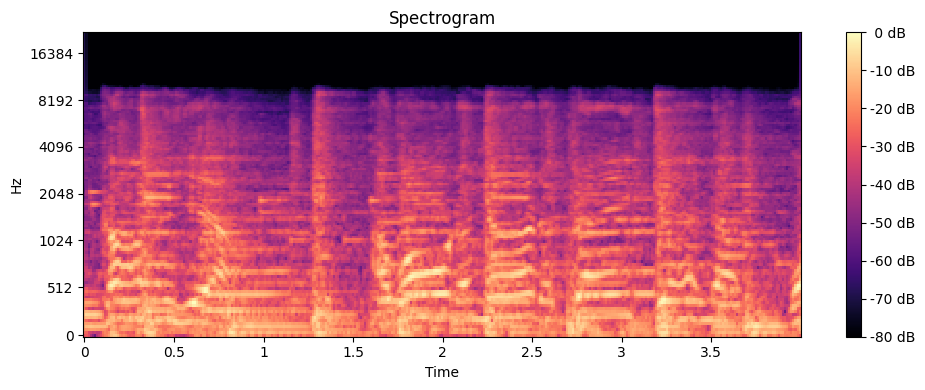

(128, 345)


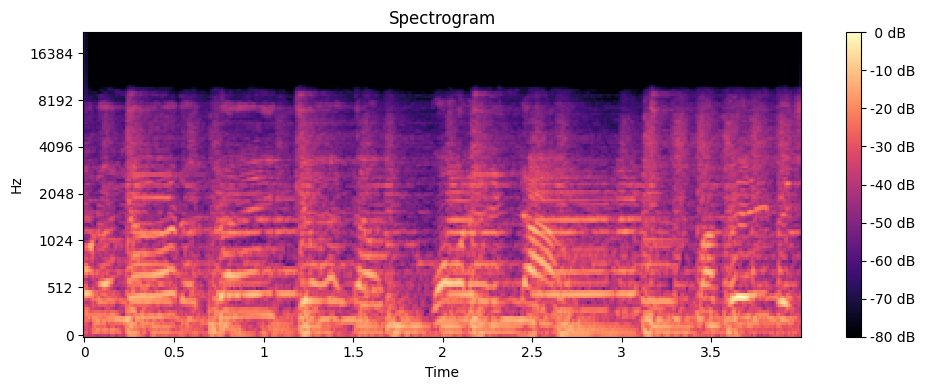

(128, 345)


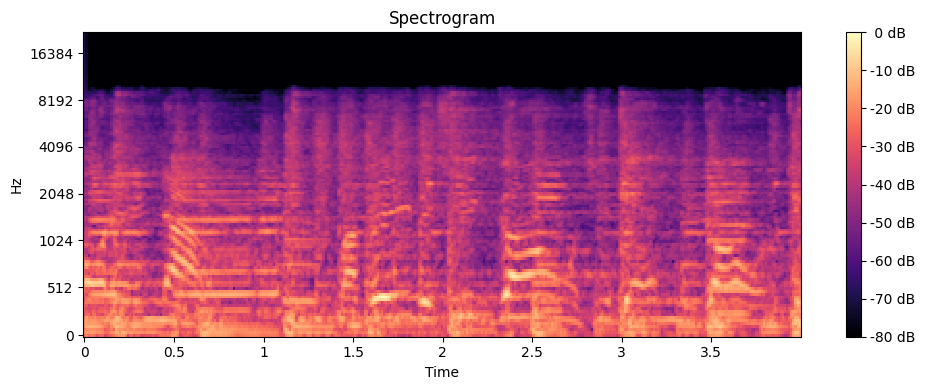

(128, 345)


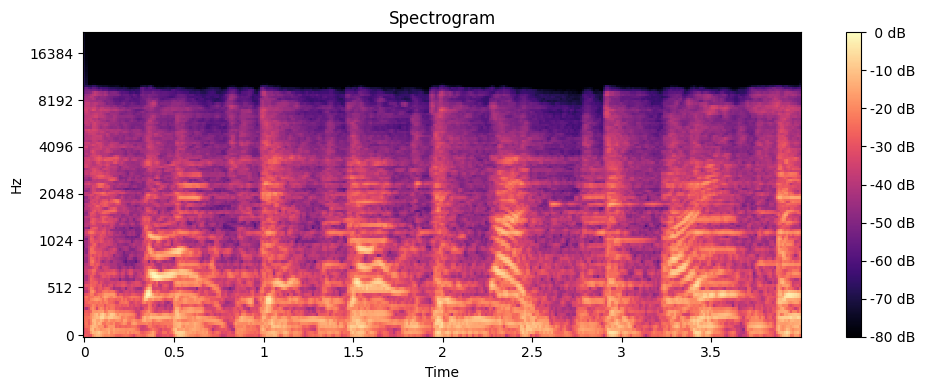

(128, 345)


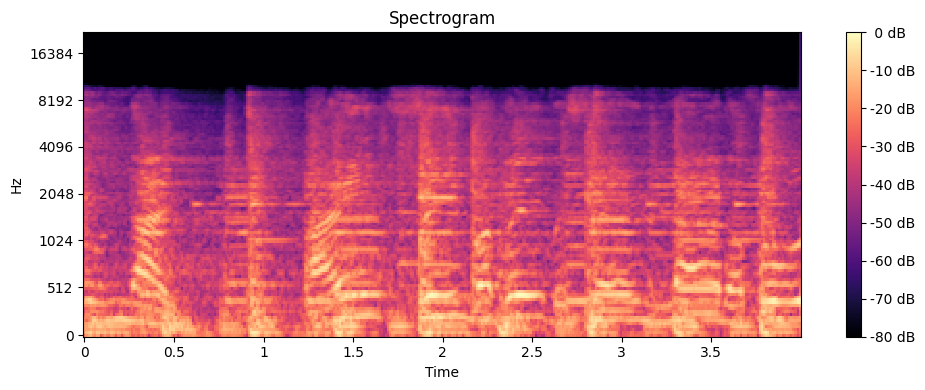

(128, 345)


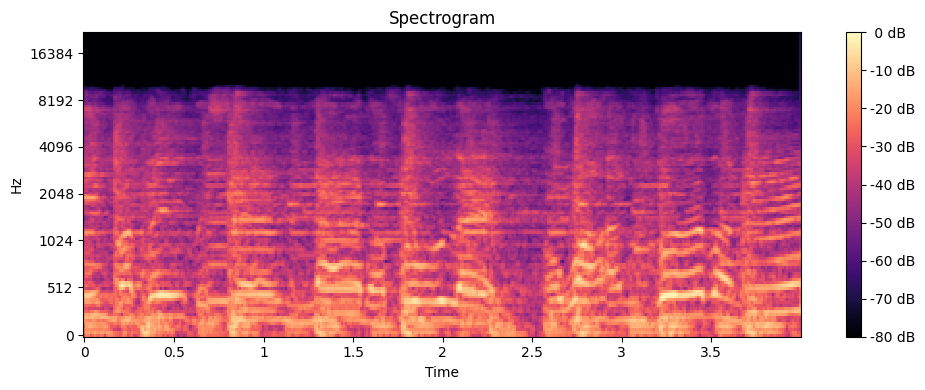

(128, 345)


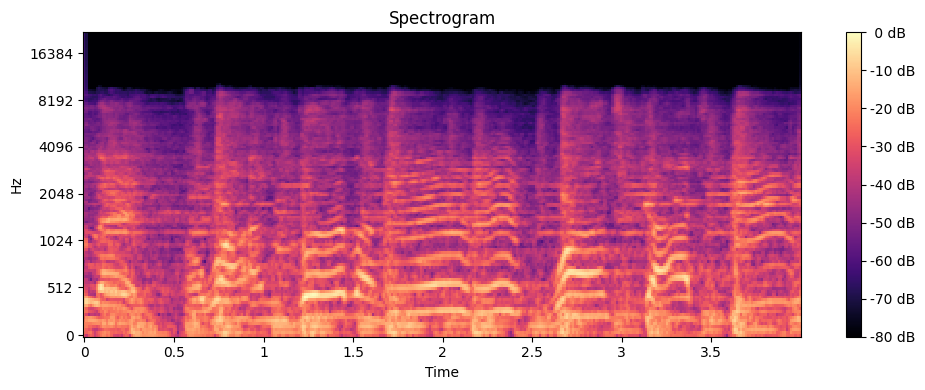

(128, 345)


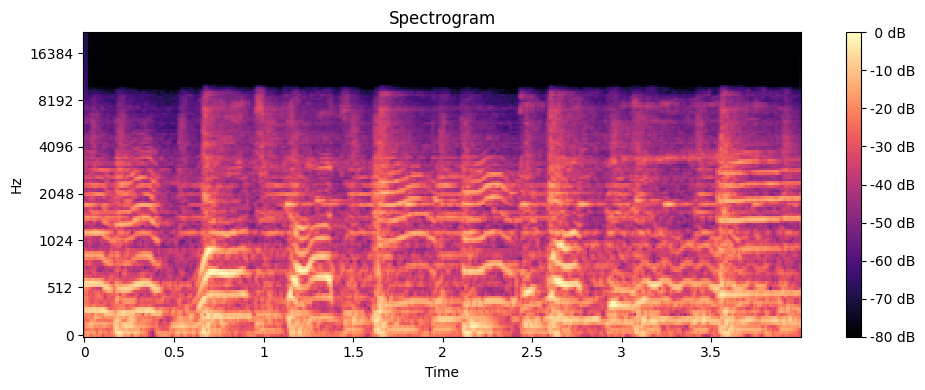

(128, 345)


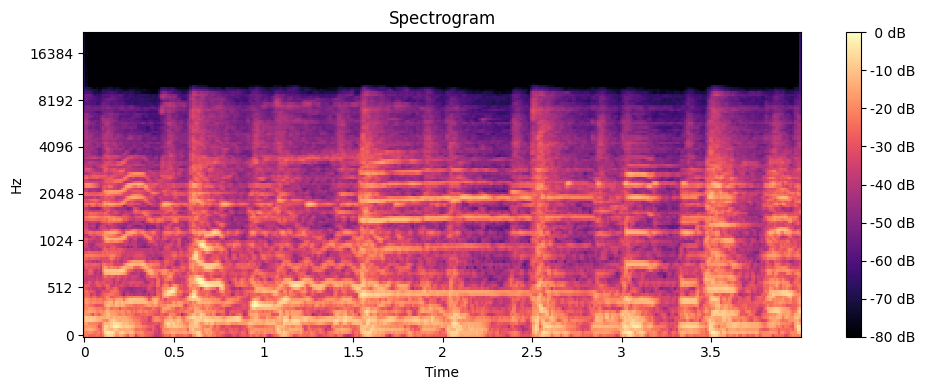

(128, 174)


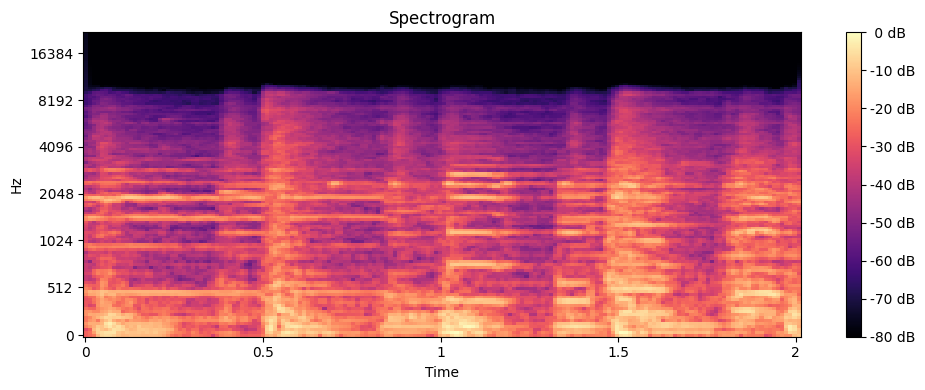

In [15]:
plot_melspectrogram_chunks(y,sr)

In [80]:
128*345

44160

In [82]:
210*210

44100

## Data Preprocessing - Final

In [20]:
#define your folder structure
data_dir = "./genres_original" # define the data folder path
classes = ['blues', 'classical','country','disco','hiphop','jazz','metal','pop','reggae','rock'] # define the classes which are folder names

In [23]:
from tensorflow.image import resize
import os
import numpy as np
import librosa

# Load and preprocess audio data
def load_and_preprocess_data(data_dir, classes, target_shape=(210,210)):
    
    data = []
    labels = []

    # Iterate over class names and their index
    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print("Processing --", class_name)

        # Iterate through files in the class folder
        for filename in os.listdir(class_dir):

            # Process only .wav files
            if filename.endswith('.wav'):
                file_path = os.path.join(class_dir, filename)

                try:
                    # Try loading the audio file
                    audio_data, sample_rate = librosa.load(file_path, sr=None)

                except Exception as e:
                    # If file is corrupted or unreadable, skip it
                    print(f"Skipping corrupted file: {file_path}")
                    continue   # move to next file

                # ---------------- Preprocessing ---------------- #

                # Define chunk duration (seconds) and overlap
                chunk_duration = 4
                overlap_duration = 2

                # Convert duration to number of samples
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate

                # If audio is shorter than chunk size, skip
                if len(audio_data) < chunk_samples:
                    continue

                # Calculate number of chunks
                num_chunks = int(
                    np.ceil((len(audio_data) - chunk_samples) / 
                            (chunk_samples - overlap_samples))
                ) + 1

                # Iterate over each chunk
                for i in range(num_chunks):

                    # Calculate start and end indices
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    # Extract chunk
                    chunk = audio_data[start:end]

                    # If chunk is smaller than expected, skip
                    if len(chunk) < chunk_samples:
                        continue

                    # Create Mel Spectrogram
                    mel_spectrogram = librosa.feature.melspectrogram(
                        y=chunk,
                        sr=sample_rate
                    )

                    # Add channel dimension and resize
                    mel_spectrogram = resize(
                        np.expand_dims(mel_spectrogram, axis=-1),
                        target_shape
                    )

                    # Append processed data and label
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    # Convert lists to numpy arrays
    return np.array(data), np.array(labels)

In [24]:
data,labels = load_and_preprocess_data(data_dir,classes)

Processing -- blues
Processing -- classical
Processing -- country
Processing -- disco
Processing -- hiphop
Processing -- jazz


C:\Users\HP\AppData\Local\Temp\ipykernel_23556\3756331096.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_data, sample_rate = librosa.load(file_path, sr=None)


Skipping corrupted file: ./genres_original\jazz\jazz.00054.wav
Processing -- metal
Processing -- pop
Processing -- reggae
Processing -- rock


In [25]:
data.shape

(13977, 210, 210, 1)

In [26]:
labels.shape

(13977,)

In [27]:
from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels,num_classes = len(classes)) # Converting labels to one-hot encoding
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [28]:
labels.shape

(13977, 10)

## Splitting of Dataset into Training and Test set

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(data,labels,test_size=0.2,random_state=42)

# Building Model

In [30]:
model = tf.keras.models.Sequential()

In [31]:
X_train[0].shape

(210, 210, 1)

In [32]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

c:\Users\HP\anaconda3\envs\DL\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [34]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [35]:
model.add(Dropout(0.3))

In [36]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [37]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [38]:
model.add(Dropout(0.3))

In [39]:
model.add(Flatten())

In [40]:
model.add(Dense(units=1200,activation='relu'))

In [41]:
model.add(Dropout(0.45))

In [42]:
#Output layer
model.add(Dense(units=len(classes),activation='softmax'))

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 210, 210, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 208, 208, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 104, 104, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 104, 104, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 102, 102, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 51, 51, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     9,831,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,555,258 (55.52 MB)

 Trainable params: 14,555,258 (55.52 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
from tensorflow.keras.optimizers import Adam
#Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [49]:
#Training Model
training_history = model.fit(X_train,Y_train,epochs=1,batch_size=32,validation_data=(X_test,Y_test))

350/350 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.3818 - loss: 1.7240 - val_accuracy: 0.5050 - val_loss: 1.3556


In [50]:
model.save("Trained_model.keras") #Mac
model.save("Trained_model.h5") #Windows

In [51]:
training_history.history

{'accuracy': [0.38180842995643616],
 'loss': [1.7240012884140015],
 'val_accuracy': [0.5050071477890015],
 'val_loss': [1.3555638790130615]}

In [52]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [21]:
X_train

array([[[[3.62469602e+00],
         [1.06304932e+00],
         [5.78081071e-01],
         ...,
         [7.72284317e+01],
         [4.75934067e+01],
         [1.37238359e+01]],

        [[6.16288261e+01],
         [1.11565666e+02],
         [1.24939728e+02],
         ...,
         [2.26902710e+02],
         [1.67433502e+02],
         [9.14233856e+01]],

        [[9.65764847e+01],
         [1.58142334e+02],
         [1.55722260e+02],
         ...,
         [2.27748688e+02],
         [3.04347015e+02],
         [1.79836197e+02]],

        ...,

        [[5.75669517e-04],
         [1.67717793e-04],
         [4.96678513e-05],
         ...,
         [8.38105916e-05],
         [8.60303917e-05],
         [1.59282630e-04]],

        [[5.21527836e-04],
         [1.09017732e-04],
         [2.23153370e-06],
         ...,
         [8.25764164e-06],
         [1.78673235e-05],
         [1.52539389e-04]],

        [[5.25240088e-04],
         [1.06741449e-04],
         [1.71574825e-07],
         ...,
 

In [53]:
#Reloading model variable
model = tf.keras.models.load_model("Trained_model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 210, 210, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 208, 208, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 104, 104, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 104, 104, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 102, 102, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 51, 51, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │     9,831,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,555,260 (55.52 MB)

 Trainable params: 14,555,258 (55.52 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [54]:
#Reloading Training history
import json
with open("training_hist.json",'r') as json_file:
    training_history_data = json.load(json_file)

In [55]:
training_history_data.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Model Evaluation - I

In [56]:
#Model evaluation on Training set
train_loss,train_accuracy = model.evaluate(X_train,Y_train)

350/350 ━━━━━━━━━━━━━━━━━━━━ 112s 318ms/step - accuracy: 0.5198 - loss: 1.3235


In [57]:
train_loss,train_accuracy

(1.3234853744506836, 0.5198103785514832)

In [58]:
#Model evaluation on Validation set
val_loss,val_accuracy = model.evaluate(X_test,Y_test)

88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 318ms/step - accuracy: 0.5050 - loss: 1.3556


In [59]:
val_loss,val_accuracy

(1.3555638790130615, 0.5050071477890015)

In [61]:
training_history_data['val_loss']

[1.3555638790130615]

## Accuracy and Loss Visualization

ValueError: x and y must have same first dimension, but have shapes (30,) and (1,)

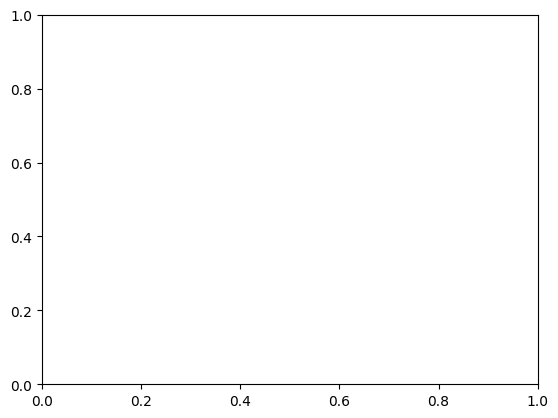

In [62]:
#Visualization of Loss
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history_data['loss'],label="Training Loss",color='red')
plt.plot(epochs,training_history_data['val_loss'],label="Validation Loss",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (30,) and (1,)

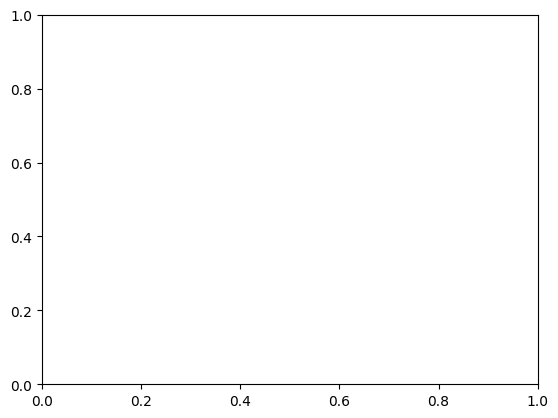

In [63]:
#Visualization of Accuracy
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history_data['accuracy'],label="Training Accuracy",color='red')
plt.plot(epochs,training_history_data['val_accuracy'],label="Validation Accuracy",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

## Precision,Recall,Confusion Matrix - Model Evaluation-II

In [64]:
X_test.shape

(2796, 210, 210, 1)

In [65]:
y_pred = model.predict(X_test)
y_pred

88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 340ms/step


array([[2.2753956e-02, 7.2534025e-01, 2.5856990e-02, ..., 4.6376148e-03,
        1.5281285e-02, 2.3238240e-02],
       [1.0748004e-01, 3.4702170e-01, 4.6869855e-02, ..., 1.3987822e-02,
        1.1159154e-01, 5.5834290e-02],
       [7.5213671e-02, 3.6830637e-03, 2.3386793e-02, ..., 5.6911252e-02,
        5.5310279e-01, 3.7646145e-02],
       ...,
       [4.7917955e-02, 6.9141079e-04, 9.9948766e-03, ..., 7.2576195e-02,
        5.4612821e-01, 1.6243855e-02],
       [1.0605218e-03, 1.6409890e-06, 1.5582693e-04, ..., 2.6141560e-01,
        6.1229885e-02, 5.6574942e-04],
       [2.3368147e-01, 1.6097605e-02, 2.7110219e-01, ..., 1.9382013e-02,
        1.7743286e-02, 2.6345634e-01]], dtype=float32)

In [66]:
y_pred.shape

(2796, 10)

In [67]:
predicted_categories = np.argmax(y_pred,axis=1)
predicted_categories

array([1, 1, 8, ..., 8, 4, 2])

In [68]:
Y_test

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [69]:
Y_test.shape

(2796, 10)

In [70]:
true_categories = np.argmax(Y_test,axis=1)
true_categories

array([1, 5, 8, ..., 4, 4, 2])

In [71]:
classes

['blues',
 'classical',
 'country',
 'disco',
 'hiphop',
 'jazz',
 'metal',
 'pop',
 'reggae',
 'rock']

In [72]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(true_categories,predicted_categories)
# Precision Recall F1score
print(classification_report(true_categories,predicted_categories,target_names=classes))

              precision    recall  f1-score   support

       blues       0.48      0.70      0.57       290
   classical       0.54      0.86      0.67       272
     country       0.51      0.12      0.19       296
       disco       0.61      0.42      0.50       263
      hiphop       0.60      0.57      0.59       294
        jazz       0.40      0.29      0.33       269
       metal       0.50      0.90      0.65       289
         pop       0.72      0.34      0.46       296
      reggae       0.48      0.61      0.54       257
        rock       0.28      0.24      0.26       270

    accuracy                           0.51      2796
   macro avg       0.51      0.51      0.48      2796
weighted avg       0.52      0.51      0.47      2796



## Confusion Matrix Visualization

In [73]:
cm

array([[203,   7,   6,   7,   4,  17,  16,   3,   8,  19],
       [  0, 235,   6,   0,   0,  16,   1,   0,   0,  14],
       [ 54,  33,  35,   4,   1,  41,  40,   2,   5,  81],
       [ 10,   2,   1, 110,   9,   1,  42,  18,  58,  12],
       [  7,   8,   1,  19, 168,   1,  22,  10,  58,   0],
       [ 43, 108,   7,   0,   1,  77,  12,   0,   5,  16],
       [  3,   2,   1,   5,   1,   0, 261,   1,   4,  11],
       [ 31,   6,   3,  21,  74,   8,  20, 100,  19,  14],
       [ 41,  11,   2,   7,  18,   9,   5,   2, 157,   5],
       [ 32,  22,   6,   7,   2,  22, 100,   2,  11,  66]])

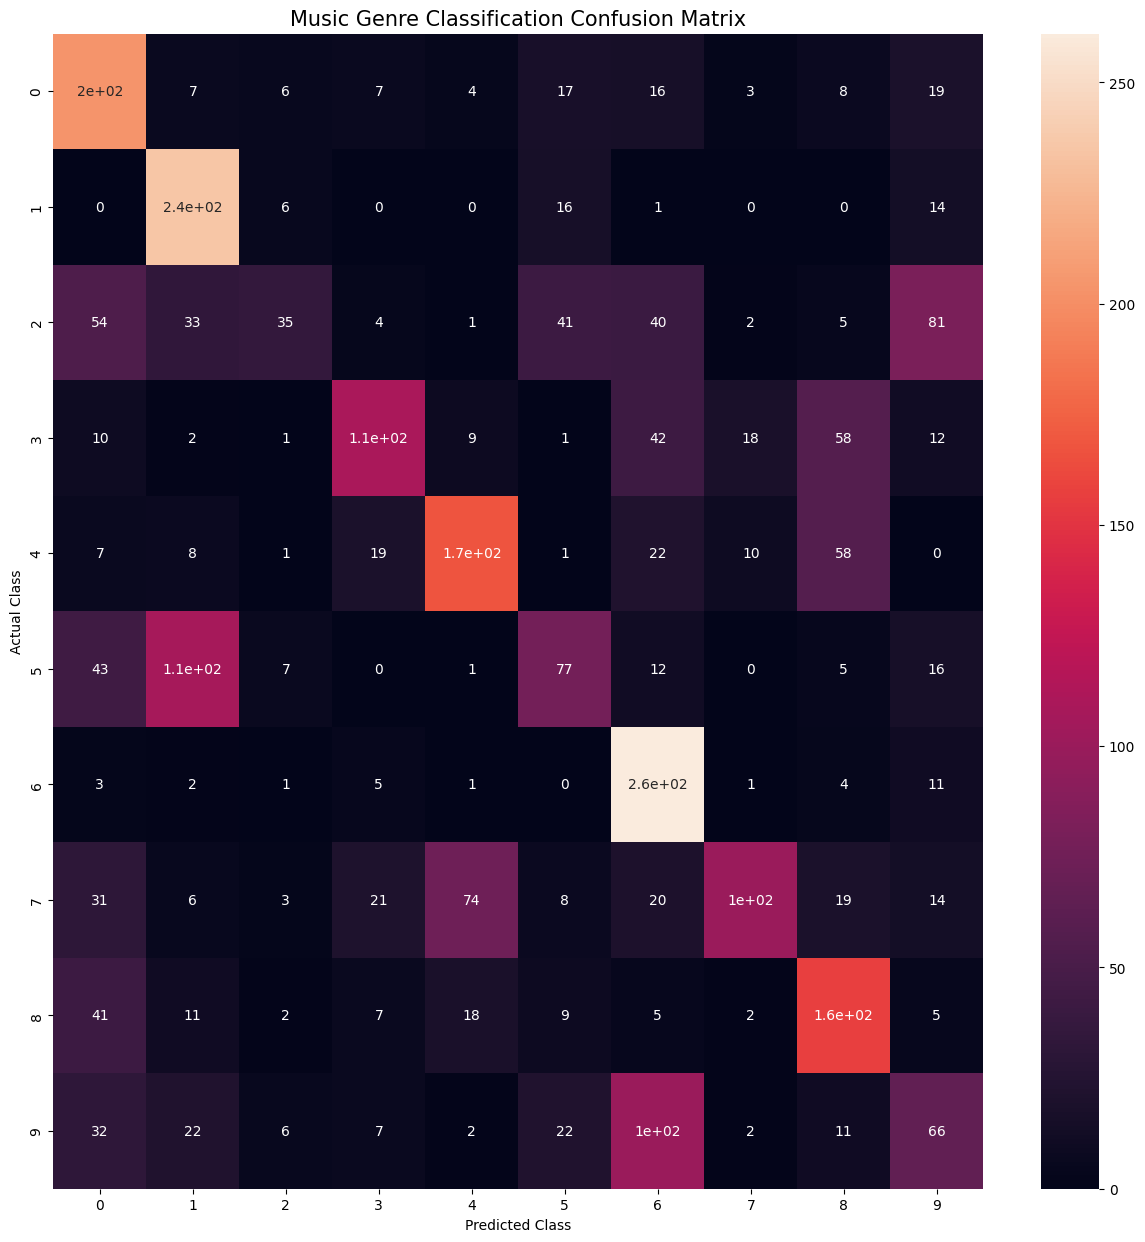

In [74]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()